In [12]:
# import modules to be used in this notebook

from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')


### Generate Scratchers 


In [13]:
# this is a hypothetical model of the numbers used in generating the tickets 
# Is this sampling with or without replacement? 
#prize_list = make_array(0, 2, 4, 8, 10, 18, 30, 88, 100, 888)
prize_list = make_array(10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
np.random.choice(prize_list, 6)

array([40, 90, 10, 60, 20, 70])

What is the chance of buying a winning ticket? Although it's possible to solve this probability problem by using counting techniques, it is much easier to just generate a lot of tickets and see how many will win.  

In [165]:
# the prize numbers may not be equally likely. In such case, weights can be used in random.choice
# these weights need to add up to 1
weights = make_array(0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.05, 0.05)

def unfair_generate_scratchers(n):
    unfair_winning_prizes = make_array()
    for i in np.arange(n):
        ticket = np.random.choice(prize_list, 6, p=weights)
        #ticket = np.random.choice(prize_list, 6)
        for prize in prize_list:
            number_matches = np.count_nonzero(ticket == prize)
            if number_matches >= 3:
                unfair_winning_prizes = np.append(unfair_winning_prizes, prize)
            if number_matches > 3:
                break
    return unfair_winning_prizes
    
unfair_prizes = unfair_generate_scratchers(10000)

unfair_scratchers = Table().with_columns("Prize", unfair_prizes)
unfair_scratchers.group("Prize")
#unfair_scratchers.to_csv("scratcher_winning_uf.csv")

Prize,count
10,981
20,158
30,162
40,135
50,160
60,162
70,149
80,144
90,21
100,23


In [167]:
unfair_scratchers.to_csv("scratcher_winning_uf.csv")

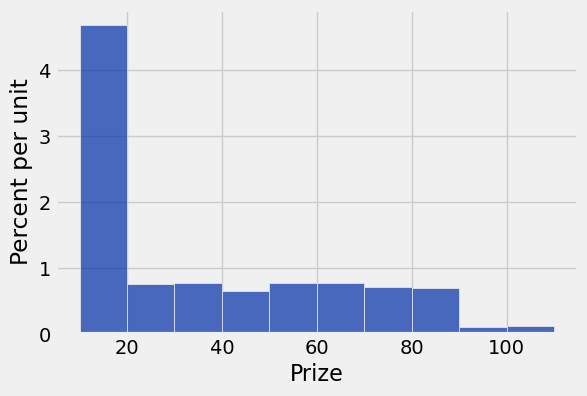

In [166]:
bins_size = np.arange(10, 111, 10)
unfair_scratchers.hist("Prize", bins=bins_size)

In [8]:
# the prize numbers may not be equally likely. In such case, weights can be used in random.choice
# these weights need to add up to 1
# weights = make_array(0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.05, 0.05)
"""
def generate_scratchers(n):
    num_wins = 0
    for i in np.arange(n):
        #ticket = np.random.choice(prize_list, 6, p = weights)
        ticket = np.random.choice(prize_list, 6)
        for prize in prize_list:
            number_matches = np.count_nonzero(ticket == prize)
            if number_matches >= 3:
                print("Winning $"+str(prize))
                num_wins = num_wins + 1
    return num_wins
generate_scratchers(1000)
"""

'\ndef generate_scratchers(n):\n    num_wins = 0\n    for i in np.arange(n):\n        #ticket = np.random.choice(prize_list, 6, p = weights)\n        ticket = np.random.choice(prize_list, 6)\n        for prize in prize_list:\n            number_matches = np.count_nonzero(ticket == prize)\n            if number_matches >= 3:\n                print("Winning $"+str(prize))\n                num_wins = num_wins + 1\n    return num_wins\ngenerate_scratchers(1000)\n'